# C-SON Domain Map

Generates a global map showing all candidate ROMS grid domains.

In [1]:
import yaml
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean
import roms_tools as rt

In [2]:
def read_yaml(path):
    """Return dict of {name: grid_kwargs} from a grids YAML file."""
    with open(path) as f:
        data = yaml.safe_load(f)
    return data["grids"]

In [3]:
grids_config = read_yaml("grids.yml")

grids = {}
states = {}
for name, info in grids_config.items():
    print(f"Building grid: {name}")
    kw = dict(info["grid_kwargs"])
    kw.setdefault("topography_source", {"name": "ETOPO5"})
    grids[name] = rt.Grid(**kw)
    states[name] = info.get("state")

print(f"\nBuilt {len(grids)} grids.")

Building grid: california_current


Building grid: humboldt_current


Building grid: benguela_current


Building grid: canary_current


Building grid: gulf_of_guinea


...

Building grid: oceania


Building grid: pacific-100km


Building grid: atlantic-100km


Building grid: indian-100km



Built 18 grids.


In [4]:
CENTRAL_LON = 305.0
# Map seam longitude: the left/right edge of a global Robinson projection
SEAM = CENTRAL_LON - 180  # 125°E


def _normalize_lon(lon_raw, seam):
    """Shift longitudes into [seam, seam+360) so each grid is continuous."""
    return (lon_raw - seam) % 360 + seam


def pcolormesh_wrapsafe(ax, g, seam, **kwargs):
    """Plot a roms_tools Grid with correct dateline/seam handling.

    Normalises longitudes to [seam, seam+360) and masks cells whose corners
    jump >180° across the seam, so pcolormesh does not draw a stripe across
    the whole map.
    """
    lon = _normalize_lon(g.ds.lon_rho.values, seam)
    lat = g.ds.lat_rho.values
    h = g.ds.h.values.astype(float)

    dxi = np.abs(np.diff(lon, axis=1))
    deta = np.abs(np.diff(lon, axis=0))
    bad = np.zeros(h.shape, dtype=bool)
    bad[:, :-1] |= dxi > 180
    bad[:, 1:]  |= dxi > 180
    bad[:-1, :] |= deta > 180
    bad[1:, :]  |= deta > 180

    h_masked = np.where(bad, np.nan, h)
    ax.pcolormesh(lon, lat, h_masked, transform=ccrs.PlateCarree(), **kwargs)


def perimeter_wrapsafe(ax, g, seam, **kwargs):
    """Plot the perimeter of a roms_tools Grid as a closed polyline.

    Walks the four edges of the (lat_rho, lon_rho) arrays, normalises
    longitudes to [seam, seam+360), and splits the line wherever it
    jumps the seam (>180° between adjacent points) so no stripe is drawn.
    """
    lon_raw = g.ds.lon_rho.values
    lat = g.ds.lat_rho.values

    # Walk the boundary clockwise and close the polygon
    edge_lon = np.concatenate([
        lon_raw[0, :],
        lon_raw[1:, -1],
        lon_raw[-1, -2::-1],
        lon_raw[-2:0:-1, 0],
        lon_raw[0:1, 0],
    ])
    edge_lat = np.concatenate([
        lat[0, :],
        lat[1:, -1],
        lat[-1, -2::-1],
        lat[-2:0:-1, 0],
        lat[0:1, 0],
    ])

    edge_lon = _normalize_lon(edge_lon, seam)

    breaks = np.where(np.abs(np.diff(edge_lon)) > 180)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends   = np.concatenate([breaks + 1, [len(edge_lon)]])

    for s, e in zip(starts, ends):
        if e - s > 1:
            ax.plot(edge_lon[s:e], edge_lat[s:e],
                    transform=ccrs.PlateCarree(), **kwargs)

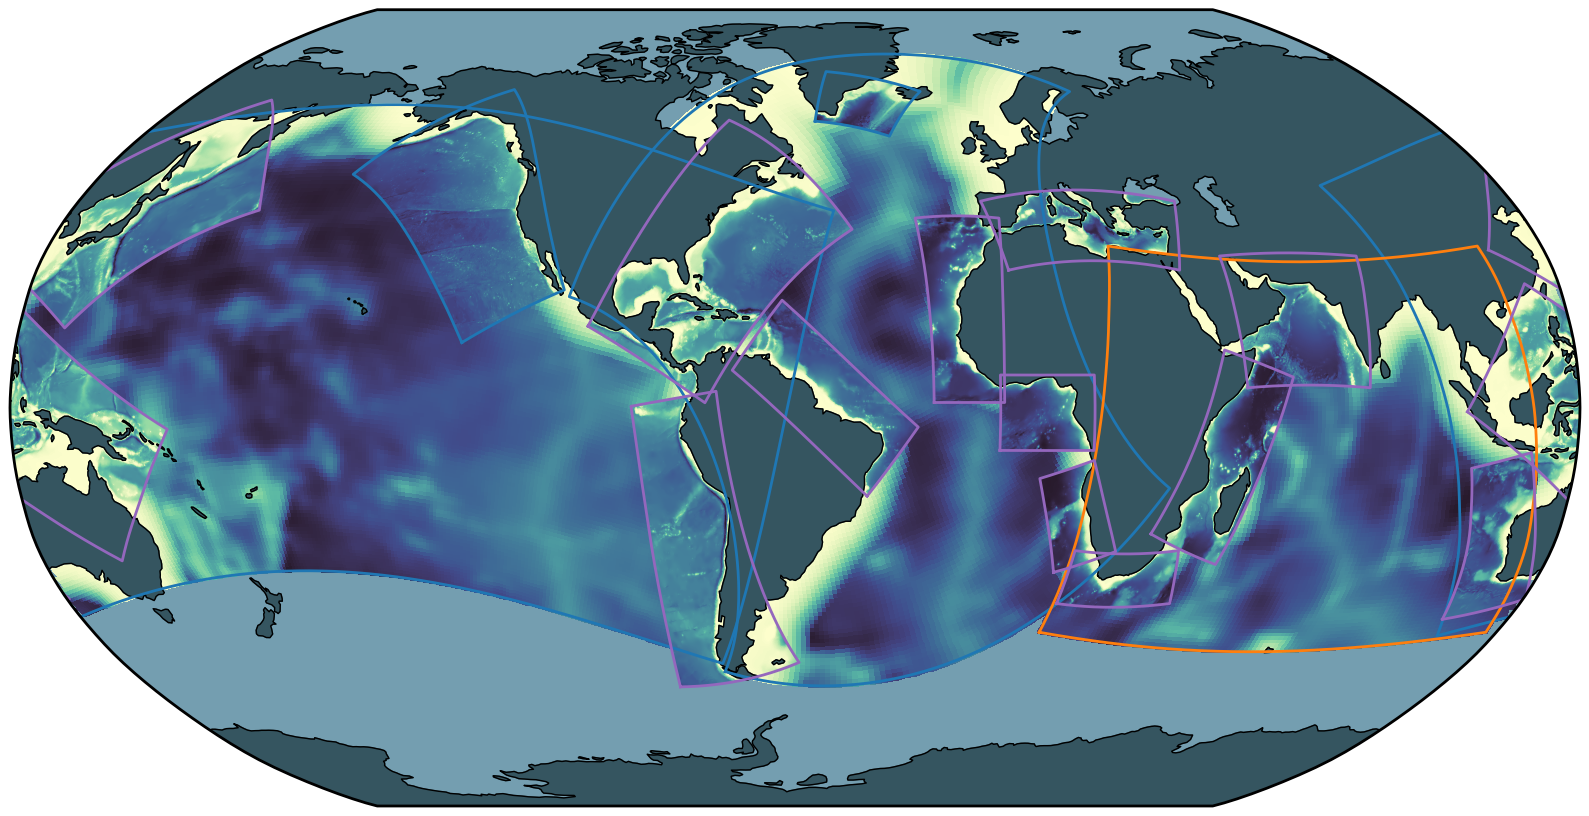

In [5]:
BASIN_GRIDS = {'pacific-100km', 'atlantic-100km', 'indian-100km'}

STATE_COLORS = {
    'Scientifically Validated': 'tab:blue',
    'Functionally Validated':   'tab:orange',
    None:                       'tab:purple',
}
EDGE_LINEWIDTH = 2.0

prj = ccrs.Robinson(central_longitude=CENTRAL_LON)

fig, ax = plt.subplots(
    figsize=(16, 9),
    facecolor='none',
    subplot_kw=dict(projection=prj),
)
ax.set_facecolor('none')

ax.add_feature(
    cartopy.feature.NaturalEarthFeature(
        'physical', 'ocean', '110m',
        edgecolor='face',
        facecolor='#749EB0',
        zorder=-9999,
    )
)

ax.add_feature(
    cartopy.feature.NaturalEarthFeature(
        'physical', 'land', '110m',
        edgecolor='face',
        facecolor='#355560',
    )
)

ax.coastlines()

ax.spines['geo'].set_visible(True)
ax.spines['geo'].set_linewidth(2)
ax.spines['geo'].set_edgecolor('black')

basin = {n: g for n, g in grids.items() if n in BASIN_GRIDS}
regional = {n: g for n, g in grids.items() if n not in BASIN_GRIDS}

# Fill: basin grids first (under), then regional grids on top
for name, g in basin.items():
    pcolormesh_wrapsafe(ax, g, SEAM, cmap=cmocean.cm.deep)
for name, g in regional.items():
    pcolormesh_wrapsafe(ax, g, SEAM, cmap=cmocean.cm.deep)

# Perimeters coloured by validation state; basin first so regional outlines
# sit on top at overlaps
for name, g in basin.items():
    perimeter_wrapsafe(ax, g, SEAM,
                       color=STATE_COLORS[states[name]],
                       linewidth=EDGE_LINEWIDTH)
for name, g in regional.items():
    perimeter_wrapsafe(ax, g, SEAM,
                       color=STATE_COLORS[states[name]],
                       linewidth=EDGE_LINEWIDTH)

ax.set_global()

fig.tight_layout()
fig.savefig('cson-map.png', dpi=300, transparent=True)

plt.show()

**Figure: Domains in the C-Star Ocean Network.** Each rectangle delineates a ROMS grid configuration on a global Robinson projection. Perimeter color denotes the validation state of the configuration:

- **blue — Scientifically validated:** the configuration's ocean (and biogeochemical, where applicable) solution has been evaluated against observations.
- **orange — Functionally validated:** the configuration runs end-to-end and produces a stable solution, but has not yet been scientifically validated.
- **purple — Illustrative of potential extensions to the network:** candidate domains whose geometries are defined here but which are not yet configured.

All domains shown are supported by the [C-Star](https://github.com/CWorthy-ocean/C-Star) reproducible workflow framework, which enables users to build and operate any of these models on a supported machine.